# Pre-processing the dataset:

In [107]:
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer
from scipy.sparse import hstack

DATASET_PATH = "../datasets"

df = pd.read_csv(f"{DATASET_PATH}/labeled_data/final_training_dataset_ready.csv")


# Fixed Epoch: 01/01/2026
REF_DATE = 1767225600 
ONE_YEAR = 365 * 86400

df["recency_score"] = 1 / ((REF_DATE - df["mod_time_unix"]) / ONE_YEAR + 1)
df["size_logged"] = np.log1p(df["size_bytes"])
df["name_len"] = df["filename"].apply(len)
df["path_len"] = df["path"].apply(len)
df["path_depth"] = df["path"].apply(lambda p: p.count("/") + p.count("\\"))

# Initialize HashingVectorizer
hashing_vectorizer = HashingVectorizer(
    n_features=1024,
    analyzer="char",
    norm=None,
    alternate_sign=False,
    ngram_range=(4, 4),
)

# Apply feature hashing to the 'filename' column
filename_vectors = hashing_vectorizer.fit_transform(df["filename"])
path_vectors = hashing_vectorizer.fit_transform(df["path"])

df

,filename,path,extension,size_bytes,mod_time_unix,source_user,source_type,label_finance,label_hr,label_it,label_general,recency_score,size_logged,name_len,path_len,path_depth
0,mc_stats.php,\\wsl$\Ubuntu\home\richardhall\projects\hoosie...,.php,668,1.743022e+09,richardhall,github_real,0,0,0,0,0.565770,6.505784,12,51,8
1,08-32507_In re Davis (707(b))_maw.wpd,C:\Users\zphillips\OneDrive - Corp\Work\Misc\D...,.wpd,73400,1.488968e+09,zphillips,govdoc_real,0,0,0,0,0.101797,11.203693,37,50,6
2,07a0121p-06.txt,C:\Users\nholmes\Documents\Personal\Docs,.txt,62914,1.764981e+09,nholmes,govdoc_real,0,0,0,0,0.933560,11.049540,15,40,5
3,DMC_07162001_2-01cv04_WIRELESS_V_CUMULUS.pdf,Z:\HR\Recruiting\Reqs\2024\Wireless,.pdf,31457,1.483660e+09,hansondustin,govdoc_real,0,0,0,0,0.100082,10.356409,44,35,5
4,package.json,C:\Users\pricebrian\Dev\moodle-logstore_xapi\s...,.json,159801,1.765613e+09,structural_toxic_gen,dependency_noise,0,0,0,0,0.951346,11.981691,12,86,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5530,msg_22.txt,C:\Python312\Lib\email\test\data,.txt,1940,1.755676e+09,charlie,system_noise,0,0,0,0,0.731937,7.570959,10,32,5
5531,package.json,C:\Users\lozanostephanie\Dev\franchistemplate\...,.json,87340,1.705077e+09,structural_toxic_gen,dependency_noise,0,0,0,0,0.336619,11.377575,12,89,10
5532,04473a3a.so,C:\Users\rosalesbrittany\source\repos\PhillyDH...,.so,1913,1.763868e+09,structural_toxic_gen,dependency_noise,0,0,0,0,0.903775,7.556951,11,129,14
5533,Dockerfile,C:\Work\Projects\nothingcoin\src\qt\cmake\CMak...,NaN,1950294,1.736642e+09,structural_toxic_gen,dependency_noise,0,0,0,0,0.507668,14.483491,10,63,9


# Training:

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define target-specific valuable extensions
target_extension_map = {
    "label_finance": [".xlsx", ".xls", ".csv", ".pdf", ".accp", ".pptx"],
    "label_hr": [".docx", ".doc", ".rtf", ".pdf", ".xlsx", ".xls"],
    "label_it": [".pem",".key",".kdbx",".p12",".ovpn",".private",".wallet",".sql",".env"]
}

# Add "label_general" after defining the other labels
target_extension_map["label_general"] = list(
    set(
        target_extension_map["label_finance"]
        + target_extension_map["label_hr"]
        + target_extension_map["label_it"]
    )
)
common_dev_junk = [".pyc", ".pyi", ".lcl", ".pyd", ".map", ".ts", ".js", ".spec", ".test.js",]

# Define target-specific junk extensions
target_junk_map = {
    "label_finance": [".class", ".java", ".cpp", ".obj", ".dll", ".exe"]
    + common_dev_junk,
    "label_hr": [".class", ".java", ".py", ".obj", ".dll", ".exe"] + common_dev_junk,
    "label_it": [".tmp", ".log", ".cache"]
    + [ext for ext in common_dev_junk if ext not in [".ts", ".js"]],
}

target_junk_map["label_general"] = list(
    set(
        target_junk_map["label_finance"]
        + target_junk_map["label_hr"]
        + target_junk_map["label_it"]
    )
)

target_configs = {
    "label_finance": {"C": 0.1, "weight": 12},
    "label_general": {"C": 0.5, "weight": 4.0},
    "label_hr":      {"C": 1.0, "weight": 1.0},
    "label_it":      {"C": 0.3, "weight": 15.0}
}

models_map = {}

for target, config in target_configs.items():

    # Prepare Data
    df_temp = df.copy()
    df_temp["valuable_ext"] = df_temp["extension"].isin(target_extension_map[target]).astype(int)
    df_temp["junk_ext"] = df_temp["extension"].isin(target_junk_map[target]).astype(int)

    df_temp.to_csv("1.csv", index=False)

    # Create feature matrix X and target vector y for the current target
    numerical_features = df_temp[
        [
            "recency_score",
            "size_logged",
            "valuable_ext",
            "junk_ext",
            "name_len",
            "path_len",
            "path_depth",
        ]
    ].values
    X_target = hstack([numerical_features, filename_vectors, path_vectors])
    y_target = df_temp[target].values

    # Split Data
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_target, y_target, df_temp.index, test_size=0.2, random_state=42, stratify=y_target
    )

    # Train Model
    C = config["C"]
    model = LogisticRegression(solver="lbfgs", max_iter=1000,
                                C=C, class_weight={0: 1, 1: config['weight']})
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1]

    print("Accuracy for", target, ":", accuracy_score(y_test, y_pred))
    print("\nClassification Report for c =", C, ", weight =", config['weight'], ", Bias =", model.intercept_[0], ":\n", classification_report(y_test, y_pred))

    models_map[target] = model

Accuracy for label_finance : 0.983739837398374

Classification Report for c = 0.1 , weight = 12 , Bias = -6.477676913022877 :
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      1071
           1       0.70      0.86      0.78        36

    accuracy                           0.98      1107
   macro avg       0.85      0.92      0.88      1107
weighted avg       0.99      0.98      0.98      1107

Accuracy for label_general : 0.934056007226739

Classification Report for c = 0.5 , weight = 4.0 , Bias = -6.408420646593317 :
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       933
           1       0.78      0.80      0.79       174

    accuracy                           0.93      1107
   macro avg       0.87      0.88      0.88      1107
weighted avg       0.93      0.93      0.93      1107

Accuracy for label_hr : 0.980126467931346

Classification Report for c = 1.0 , weight = 1.0

# Display results

Top results for model targeting label_finance:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,source_label,actual_label,model_score
1095,RD Budget 23 pager_FINAL.docx,Z:\Finance\General_Ledger\2024,.docx,587202,29,30,3,1.765699e+09,govdoc_real,1,0.992563
293,Caribbean field guide complete with P3.docx,Z:\HR\Payroll\Cycles\2025\Complete,.docx,4624220,43,34,5,1.761513e+09,govdoc_real,1,0.986574
1076,L15S1348ComprehensiveImmigrationReformAct05150...,Z:\HR\Payroll\Cycles\2023,.docx,136314,54,25,4,1.737386e+09,govdoc_real,1,0.984318
74,Accrual measures of pension-related compensati...,Z:\HR\Payroll\Cycles\2025,.docx,136314,64,25,4,1.757634e+09,govdoc_real,1,0.977612
981,Complete980120forPdf.pdf,Z:\HR\Payroll\Cycles\2024,.pdf,5630853,24,25,4,1.756311e+09,govdoc_real,1,0.976663
400,RD Budget 23 pager_FINAL.docx,Z:\Finance\General_Ledger\2024\Final,.docx,83886,29,36,4,1.736652e+09,govdoc_real,1,0.975646
566,bailout 1-30-09 Wall Street bonuses should be ...,Z:\HR\Payroll\Cycles\2025\Right,.docx,94371,100,31,5,1.739224e+09,govdoc_real,1,0.972627
22,compiled Word doc.docx,Z:\HR\Payroll\Cycles\2023,.docx,241172,22,25,4,1.749118e+09,govdoc_real,1,0.970553
147,Budget_vs_Actuals_Q4.pptx,Z:\Finance\Reporting\Exec\2024,.pptx,4194304,25,30,4,1.749927e+09,chatGPT_finance,1,0.965745
593,FINAL budget FINAL.xlsx,C:\Users\jbarnes\Documents\finance\final,.xlsx,734003,23,40,5,1.751034e+09,chatGPT_finance,1,0.964863


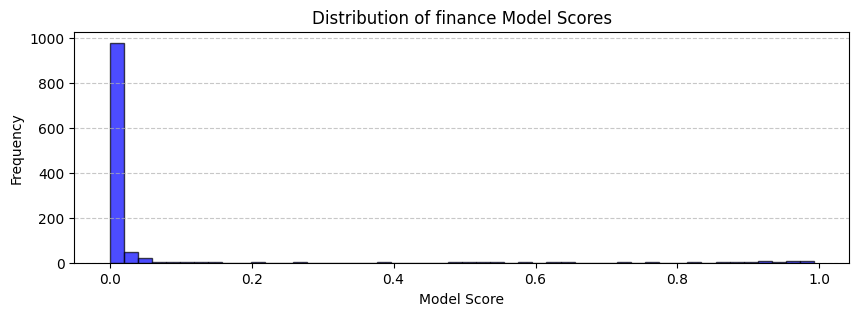

Top results for model targeting label_general:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,source_label,actual_label,model_score
727,Candidate_Tracking_Export_01.xlsx,Z:\HR\Recruiting\Exports\Legacy,.xlsx,188743,33,31,4,1.759426e+09,chatGPT_HR,1,0.999004
13,secrets.js,C:\Users\sharon66\Desktop\Coding\config,.js,1072,10,39,5,1.761196e+09,secret_injection,1,0.998806
292,MJK_09092004_2-04cv13_Bender_v_USA.pdf,Z:\HR\Recruiting\Reqs\2023,.pdf,52428,38,26,4,1.765639e+09,govdoc_real,1,0.998517
434,secrets.json,C:\Users\scottcampbell\AppData\Local,.json,3101,12,36,4,1.764718e+09,secret_injection,1,0.998475
658,database.json,C:\Users\johnhuff\Desktop\Coding,.json,813,13,32,4,1.747823e+09,secret_injection,1,0.995688
502,database.php,C:\Work\Projects\Bio-HMM-Logo\src\config,.php,2643,12,40,5,1.761165e+09,secret_injection,1,0.994843
732,config.yml,C:\Users\lozanostephanie\Desktop\Coding,.yml,1244,10,39,4,1.763647e+09,secret_injection,1,0.994525
397,secrets.js,C:\Work\Projects\avalon\localization,.js,1925,10,36,4,1.757395e+09,secret_injection,1,0.993684
928,wp-config.php,\\wsl$\Ubuntu\home\runner\auth-service,.php,833,13,38,6,1.763203e+09,secret_injection,1,0.993265
857,certificate.p12,C:\Users\ricardo01\source\repos\SiegeUnitConve...,.p12,50585,15,53,5,1.739249e+09,secret_injection,1,0.993229


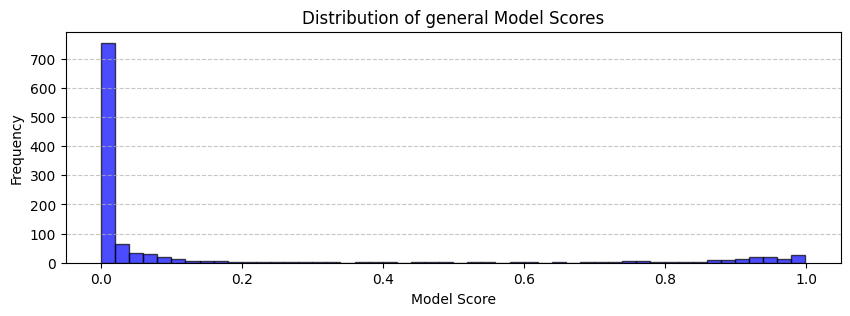

Top results for model targeting label_hr:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,source_label,actual_label,model_score
1078,DBH_05202004_2-03cv52_MASS_BAY_V_BUSHMASTER.pdf,Z:\HR\Recruiting\Reqs\2025\Mass,.pdf,41943,47,31,5,1.763035e+09,govdoc_real,1,0.982798
932,GZS_08262002_1-01cv101_SHAPIRO_v_HAENN.pdf,Z:\HR\Recruiting\Reqs\2023,.pdf,83886,42,26,4,1.748671e+09,govdoc_real,1,0.982345
506,EmployeeGuide.docx,C:\Users\scottjonathan\OneDrive - Corp\HR_Docs...,.docx,335544,18,56,5,1.762769e+09,govdoc_real,1,0.974138
60,DMC_12062006_1-06cv35_Lewis_v_Barnhart.pdf,Z:\HR\Recruiting\Reqs\2024\Barnhart,.pdf,52428,42,35,5,1.754356e+09,govdoc_real,1,0.973424
727,Candidate_Tracking_Export_01.xlsx,Z:\HR\Recruiting\Exports\Legacy,.xlsx,188743,33,31,4,1.759426e+09,chatGPT_HR,1,0.972823
843,Holland-99cv462-dsms-opn.pdf,Z:\HR\Recruiting\Reqs\2023,.pdf,31457,28,26,4,1.764486e+09,govdoc_real,1,0.971203
1018,GC_04052002_2-01cv187_Carrier_v_JPB_Enter.pdf,Z:\HR\Recruiting\Reqs\2023,.pdf,20971,45,26,4,1.766608e+09,govdoc_real,1,0.971078
292,MJK_09092004_2-04cv13_Bender_v_USA.pdf,Z:\HR\Recruiting\Reqs\2023,.pdf,52428,38,26,4,1.765639e+09,govdoc_real,1,0.963706
395,458-019 CBI publicversion.docx,Z:\HR\Recruiting\Reqs\2024\Publicversion,.docx,157286,30,40,5,1.764216e+09,govdoc_real,1,0.959090
833,USAR_CENTENNIAL_ALL_TABS_CVR.pdf,Z:\HR\Recruiting\Reqs\2025,.pdf,251658,32,26,4,1.760796e+09,govdoc_real,1,0.951937


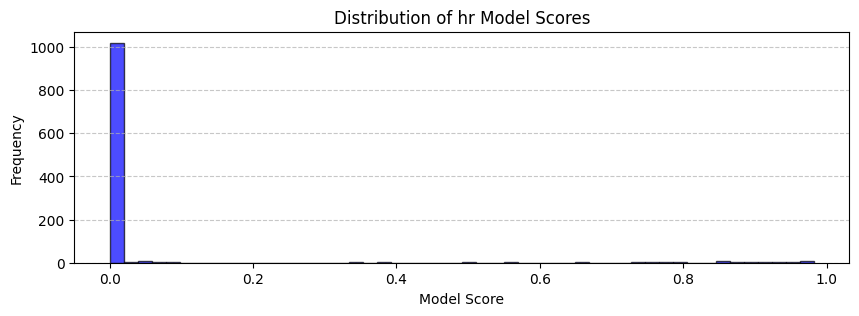

Top results for model targeting label_it:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,source_label,actual_label,model_score
658,database.json,C:\Users\johnhuff\Desktop\Coding,.json,813,13,32,4,1.747823e+09,secret_injection,1,0.998917
988,server.key,C:\Users\mcclurejamie\Desktop\Code_Review\EOLL...,.key,18353,10,54,6,1.759739e+09,secret_injection,1,0.997438
13,secrets.js,C:\Users\sharon66\Desktop\Coding\config,.js,1072,10,39,5,1.761196e+09,secret_injection,1,0.997425
732,config.yml,C:\Users\lozanostephanie\Desktop\Coding,.yml,1244,10,39,4,1.763647e+09,secret_injection,1,0.996536
502,database.php,C:\Work\Projects\Bio-HMM-Logo\src\config,.php,2643,12,40,5,1.761165e+09,secret_injection,1,0.996239
404,application.yml,\\wsl$\Ubuntu\home\dev\auth-service,.yml,2769,15,35,6,1.749755e+09,secret_injection,1,0.995767
434,secrets.json,C:\Users\scottcampbell\AppData\Local,.json,3101,12,36,4,1.764718e+09,secret_injection,1,0.994319
133,config.yml,\\wsl$\Ubuntu\home\dev\auth-service,.yml,3895,10,35,6,1.570326e+09,secret_injection,0,0.992212
318,secrets.py,\\wsl$\Debian\home\dev\backend,.py,3777,10,30,6,1.753112e+09,secret_injection,1,0.991928
451,keystore.jks,C:\Users\jbennett\Desktop\Code_Review\owl\src\...,.jks,121589,12,56,8,1.758729e+09,secret_injection,1,0.990849


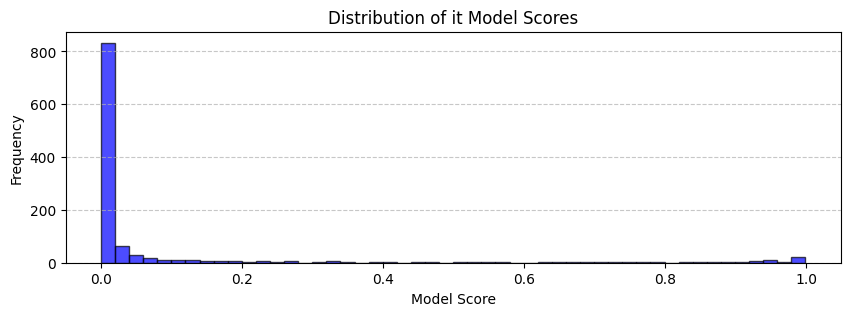

In [111]:
import matplotlib.pyplot as plt

for target, model in models_map.items():
    print(f"Top results for model targeting {target}:")

    # Get test set predictions
    y_test = df.loc[idx_test][target].values
    y_scores = model.predict_proba(X_test)[:, 1]

    results = pd.DataFrame(
        {
            "filename": df.loc[idx_test]["filename"].values,
            "filepath": df.loc[idx_test]["path"].values,
            "extension": df.loc[idx_test]["extension"].values,
            "size_bytes": df.loc[idx_test]["size_bytes"].values,
            "name_len": df.loc[idx_test]["name_len"].values,
            "path_len": df.loc[idx_test]["path_len"].values,
            "path_depth": df.loc[idx_test]["path_depth"].values,
            "mod_time_unix": df.loc[idx_test]["mod_time_unix"].values,
            "source_label": df.loc[idx_test]["source_type"].values,
            "actual_label": y_test,
            "model_score": y_scores,
        }
    )

    # Sort and slice the results
    sorted_results = results.sort_values(by="model_score", ascending=False)
    display(sorted_results[:10])

    # Plot the distribution of model scores
    plt.figure(figsize=(10, 3))
    plt.hist(
        results["model_score"], bins=50, color="blue", alpha=0.7, edgecolor="black"
    )
    plt.title(f"Distribution of {target.split("_")[1]} Model Scores")
    plt.xlabel("Model Score")
    plt.ylabel("Frequency")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# Exporting weights:

In [112]:
import os

output_path = f"../include/ModelWeights.h"

# 3. Ensure Directory Exists and Write
os.makedirs(os.path.dirname(output_path), exist_ok=True)

cpp_content = f"""
#pragma once
// AUTOMATICALLY GENERATED FILE 

#include <vector>
#include <unordered_set>
#include <string>
"""

for target, model in models_map.items():

    # Extract Parameters
    bias = model.intercept_[0]
    weights = model.coef_.flatten()
    title = target.split("_")[1].upper()
    cpp_content += f"""
const double {title}_MODEL_BIAS = {bias:.10f};

// recency score - size_logged - valuable_ext -  junk_ext - name_len - path_len - path_depth - filename features(1024) - path features(1024)
const std::vector<double> {title}_MODEL_WEIGHTS = {{
{', '.join([f'{w:.10f}' for w in weights])}}};

const std::unordered_set<std::wstring> {title}_HIGH_VAL_EXTS = {{
{', '.join([f'L"{ext}"' for ext in target_extension_map[target]])}}};

const std::unordered_set<std::wstring> {title}_JUNK_EXTS = {{
{', '.join([f'L"{ext}"' for ext in target_junk_map[target]])}}};
"""

with open(output_path, "w") as f:
    f.write(cpp_content)